### 생선의 길이를 사용하여 무게를 예측할 수 있다.
 (답이 주관식 개념. 뭔지 맞추는 거.)

In [2]:
import numpy as np
import pandas as pd

In [3]:
fish_length = np.array(
    [8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0]
     )
fish_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 
     1000.0, 1000.0]
     )

#### 길이와 무게를 산포도로 표현

In [4]:
import matplotlib.pyplot as plt

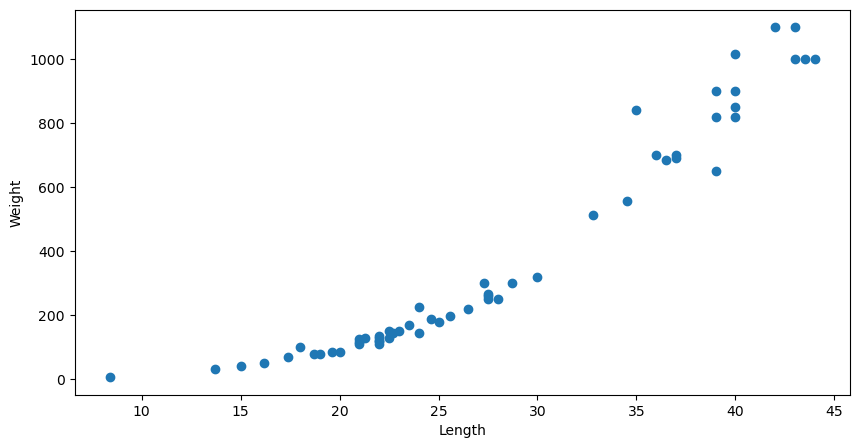

In [5]:
plt.figure(figsize=(10, 5))
plt.scatter(
    fish_length, fish_weight
)
plt.xlabel('Length')
plt.ylabel('Weight')
plt.show()

#### Train Set 과 Test Set 의 분리

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
train_input, test_input, train_target, test_target = \
    train_test_split(
        fish_length,
        fish_weight,
        random_state=42
        # stratify=fish_weight   # 얘는 주관식에서 쓰면 안 됨. 특정 분류 기준이 아니기 때문
    )

In [11]:
# 분리된 결과 확인
print(train_input.shape, test_input.shape)
print(train_target.shape, test_target.shape)

(42,) (14,)
(42,) (14,)


In [12]:
train_input

array([19.6, 22. , 18.7, 17.4, 36. , 25. , 40. , 39. , 43. , 22. , 20. ,
       22. , 24. , 27.5, 43. , 40. , 24. , 21. , 27.5, 40. , 32.8, 26.5,
       36.5, 13.7, 22.7, 15. , 37. , 35. , 28.7, 23.5, 39. , 21. , 23. ,
       22. , 44. , 22.5, 19. , 37. , 22. , 25.6, 42. , 34.5])

> 현재 Feature 은 1차원임. 하지만 얘를 나타내기 위해 대입하려면 2차원이여야 함. 차원 바꾸기 연습

In [16]:
# 1열로 구성된 배열로 재구성
train_input = train_input.reshape(-1,1)     # -1 : 알아서 해줌, 1은 1열
train_input.shape

(42, 1)

In [ ]:
test_input = test_input.reshape(-1,1)
test_input.shape            # (?) target 은 안 바꿔도 됨?

(14, 1)

#### 회귀 모델 사용

KNeighborsClassifier(kNN 객관식형) 은 원 안에 많은 유형으로 정하는 거라면,
KNeighborsRegressor(kNN 주관식형) 은 원 안에 있는 점들로 값을 유추하는 것.

In [21]:
from sklearn.neighbors import KNeighborsRegressor

In [22]:
knr = KNeighborsRegressor()  # 기본값 : 5
knr.fit(train_input, train_target)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [25]:
print(knr.score(train_input, train_target))
print(knr.score(test_input, test_target))     # 과소적합 => 사용 못 함

0.9698823289099254
0.992809406101064


> 회귀모델은 분류모델처럼 예측값과 정답값을 비교할 수 없음

### 결정계수 : 평균절대값오차 (MAE: Mean Absoulte Error)
 - 어떤 모델이 좋을 지 판단하는 기준

In [26]:
from sklearn.metrics import mean_absolute_error

In [27]:
# 테스트 세트에 대한 예측
pred = knr.predict(test_input)
pred

array([  60. ,   79.6,  248. ,  122. ,  136. ,  847. ,  311.4,  183.4,
        847. ,  113. , 1010. ,   60. ,  248. ,  248. ])

In [29]:
# 테스트 세트에 대한 평균절대값오차를 구함
mae = mean_absolute_error(test_target, pred)    # y값부터 넣고 예측치를 다음에 씀
mae

19.157142857142862

#### kNN 의 Hyper parameter 를 조절

In [30]:
# 이웃의 갯수를 3으로 설정
knr.n_neighbors = 3   # 위에 knr = KNeighborsRegressor(3) 으로 다시 줘도 되고 이렇게 바꿔줘도 됨.

# 모델을 다시 훈련
knr.fit(train_input, train_target)
print("Train:", knr.score(train_input, train_target))
print("Test:", knr.score(test_input, test_target))

Train: 0.9804899950518966
Test: 0.9746459963987609


In [31]:
# 테스트 세트에 대한 예측
pred = knr.predict(test_input)
pred

array([  47.33333333,   76.        ,  247.66666667,  120.        ,
        143.33333333,  921.66666667,  275.        ,  183.33333333,
        773.33333333,  120.        , 1033.33333333,   62.66666667,
        275.        ,  247.66666667])

In [32]:
# 테스트 세트에 대한 평균절대값오차를 구함
mae = mean_absolute_error(test_target, pred)    # y값부터 넣고 예측치를 다음에 씀
mae

35.42380952380951

#### 이웃의 갯수 조절로 확인

In [ ]:
# x축의 범위 확인
print(fish_length.min())
print(fish_length.max())

8.4
44.0


k => 3
Train Score : 0.9804899950518966
Test Score : 0.9746459963987609
--------------------------------------------------


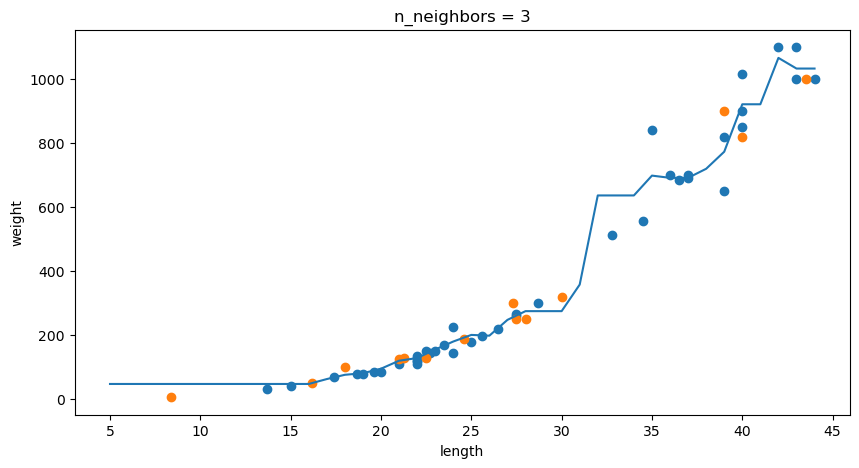

In [43]:
knr = KNeighborsRegressor()
# x 좌표 : 5 ~ 45 로 설정 (위에서 8.4 ~ 44.0 이므로)
x = np.arange(5, 45).reshape(-1, 1)

knr.n_neighbors = 3
knr.fit(train_input, train_target)
print("k =>", 3)
print("Train Score :", knr.score(train_input, train_target))
print("Test Score :", knr.score(test_input, test_target))
print("-" * 50)

# 지정한 범위 x에 대한 예측 구하기
pred = knr.predict(x)

# 훈련세트와 검증세트의 예측 결과 그래프 그리기
plt.figure(figsize=(10, 5))

plt.scatter(
    train_input,
    train_target
)

plt.scatter(
    test_input,
    test_target
)

plt.plot(x, pred)   # 괄호 안에 (x값, y값) 이 들어감.
plt.title('n_neighbors = 3')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

k => 1
Train Score : 0.9804899950518966
Test Score : 0.9746459963987609
--------------------------------------------------


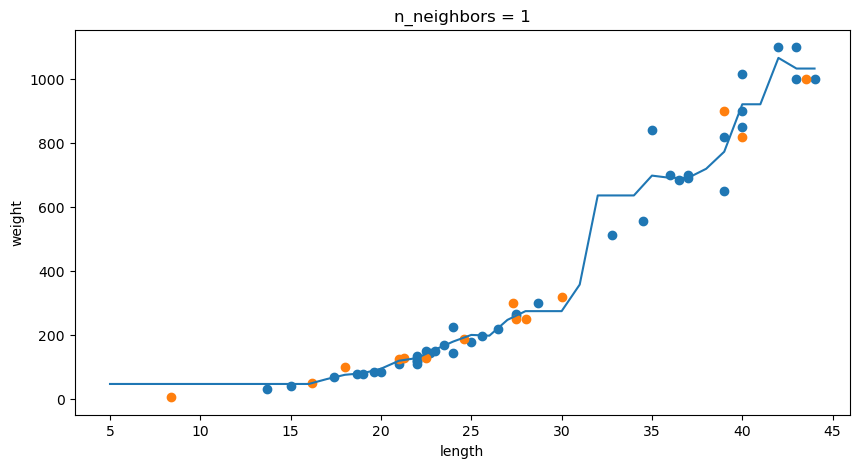

k => 3
Train Score : 0.9804899950518966
Test Score : 0.9746459963987609
--------------------------------------------------


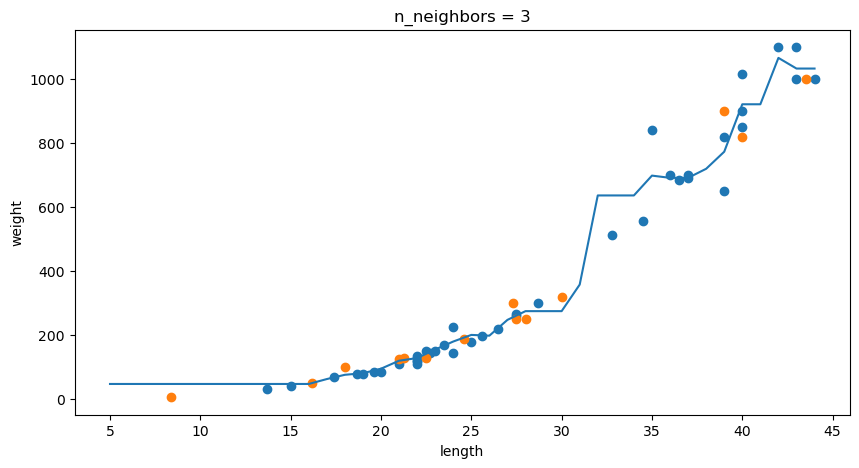

k => 5
Train Score : 0.9804899950518966
Test Score : 0.9746459963987609
--------------------------------------------------


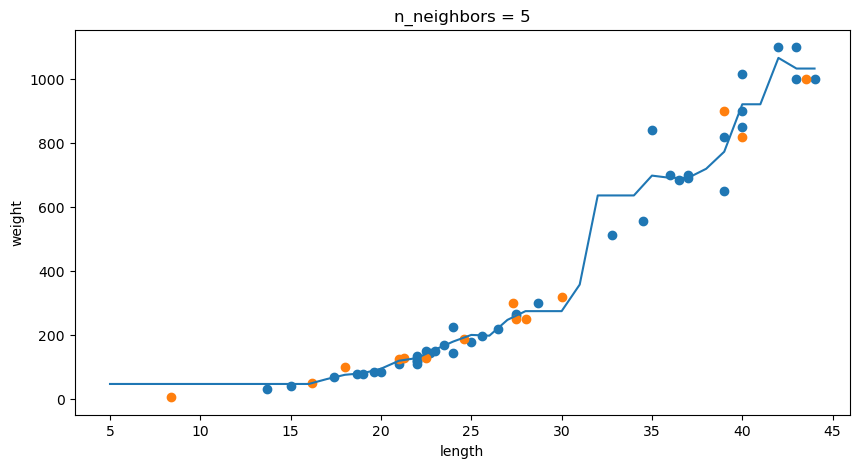

k => 10
Train Score : 0.9804899950518966
Test Score : 0.9746459963987609
--------------------------------------------------


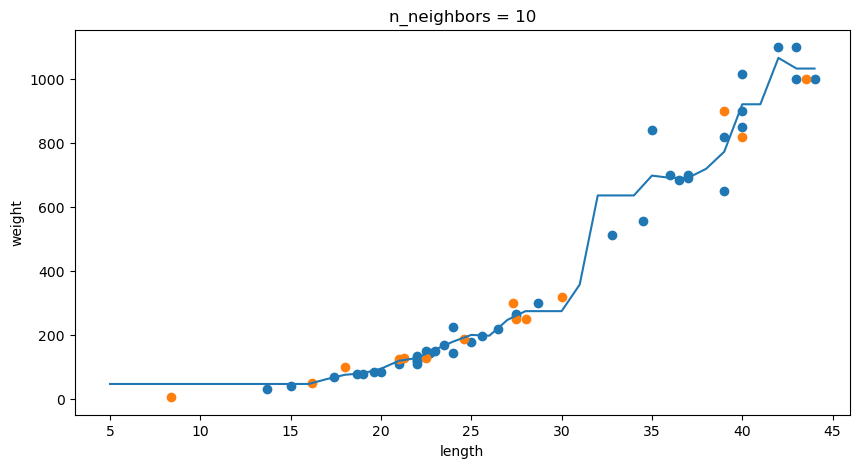

In [45]:
# 이거 수정 필요
knr = KNeighborsRegressor()
# x 좌표 : 5 ~ 45 로 설정 (위에서 8.4 ~ 44.0 이므로)
x = np.arange(5, 45).reshape(-1, 1)
for n in [1,3,5,10]:

    knr.n_neighbors = 3
    knr.fit(train_input, train_target)
    print("k =>", n)
    print("Train Score :", knr.score(train_input, train_target))
    print("Test Score :", knr.score(test_input, test_target))
    print("-" * 50)

    # 지정한 범위 x에 대한 예측 구하기
    pred = knr.predict(x)

    # 훈련세트와 검증세트의 예측 결과 그래프 그리기
    plt.figure(figsize=(10, 5))

    plt.scatter(
        train_input,
        train_target
    )

    plt.scatter(
        test_input,
        test_target
    )

    plt.plot(x, pred)
    plt.title(f'n_neighbors = {n}')
    plt.xlabel('length')
    plt.ylabel('weight')
    plt.show()